In [10]:
import pandas as pd
import numpy as np

import joblib

from collections import Counter
from scipy.stats import poisson

In [4]:
# Cargo los dos modelos de Poisson, las características actuales de cada selección y el calendario del Mundial.
home_results = joblib.load(
    "../models/home_poisson.pkl"
)

away_results = joblib.load(
    "../models/away_poisson.pkl"
)

team_strength = pd.read_csv(
    "../data/processed/team_strength.csv",
    index_col=0
)

worldcup_df = pd.read_csv(
    "../data/interim/worldcup2026_matches.csv"
)

worldcup_df["date"] = pd.to_datetime(
    worldcup_df["date"]
)

In [4]:
# Esta función utiliza los modelos entrenados para estimar la cantidad esperada de goles de ambos equipos. 
# Para ello toma el Elo y las estadísticas recientes de cada selección y genera los parámetros λ que 
# luego utiliza la distribución de Poisson.

def predict_match(
    home_team,
    away_team
):

    home = team_strength.loc[home_team]
    away = team_strength.loc[away_team]

    elo_diff = (
        home["elo"]
        - away["elo"]
    )

    away_elo_diff = (
        away["elo"]
        - home["elo"]
    )

    # -------------------------
    # HOME MODEL
    # -------------------------

    home_data = pd.DataFrame({

        "elo_diff": [elo_diff],

        "home_form_5": [
            home["form_5"]
        ],

        "away_form_5": [
            away["form_5"]
        ],

        "home_avg_goals_5": [
            home["avg_goals_5"]
        ],

        "away_avg_goals_5": [
            away["avg_goals_5"]
        ],

        "home_avg_conceded_5": [
            home["avg_conceded_5"]
        ],

        "away_avg_conceded_5": [
            away["avg_conceded_5"]
        ],

        "home_avg_goal_diff_5": [
            home["avg_goal_diff_5"]
        ],

        "away_avg_goal_diff_5": [
            away["avg_goal_diff_5"]
        ]
    })

    home_data = home_data[
        home_results.model.exog_names[1:]
    ]

    home_data.insert(
        0,
        "const",
        1
    )

    # -------------------------
    # AWAY MODEL
    # -------------------------

    away_data = pd.DataFrame({

        "away_elo_diff": [
            away_elo_diff
        ],

        "away_form_5": [
            away["form_5"]
        ],

        "home_form_5": [
            home["form_5"]
        ],

        "away_avg_goals_5": [
            away["avg_goals_5"]
        ],

        "home_avg_goals_5": [
            home["avg_goals_5"]
        ],

        "away_avg_conceded_5": [
            away["avg_conceded_5"]
        ],

        "home_avg_conceded_5": [
            home["avg_conceded_5"]
        ],

        "away_avg_goal_diff_5": [
            away["avg_goal_diff_5"]
        ],

        "home_avg_goal_diff_5": [
            home["avg_goal_diff_5"]
        ]
    })

    away_data = away_data[
        away_results.model.exog_names[1:]
    ]

    away_data.insert(
        0,
        "const",
        1
    )

    lambda_home = float(
        home_results.predict(
            home_data
        ).iloc[0]
    )

    lambda_away = float(
        away_results.predict(
            away_data
        ).iloc[0]
    )

    return {
        "home_team": home_team,
        "away_team": away_team,
        "lambda_home": lambda_home,
        "lambda_away": lambda_away
    }

In [5]:
# Genera goles aleatorios usando Poisson
def simulate_match(
    home_team,
    away_team
):

    prediction = predict_match(
        home_team,
        away_team
    )

    home_goals = poisson.rvs(
        prediction["lambda_home"]
    )

    away_goals = poisson.rvs(
        prediction["lambda_away"]
    )

    return (
        home_goals,
        away_goals
    )

# Con los goles esperados obtenidos por el 
# modelo genero un resultado posible del partido mediante una distribución de Poisson

In [6]:
# Recorro todas las combinaciones posibles de goles y calculo 
# la probabilidad total de victoria local, empate o victoria visitante.

def match_probabilities(
    home_team,
    away_team,
    max_goals=10
):

    prediction = predict_match(
        home_team,
        away_team
    )

    home_lambda = prediction[
        "lambda_home"
    ]

    away_lambda = prediction[
        "lambda_away"
    ]

    home_win = 0
    draw = 0
    away_win = 0

    for i in range(max_goals + 1):

        for j in range(max_goals + 1):

            p = (
                poisson.pmf(
                    i,
                    home_lambda
                )
                *
                poisson.pmf(
                    j,
                    away_lambda
                )
            )

            if i > j:
                home_win += p

            elif i == j:
                draw += p

            else:
                away_win += p

    return {
        "home_team": home_team,
        "away_team": away_team,
        "home_win": home_win,
        "draw": draw,
        "away_win": away_win
    }

In [7]:
# Realizo miles de simulaciones independientes del 
# mismo partido para estimar experimentalmente las probabilidades.
def monte_carlo_match(
    home_team,
    away_team,
    simulations=10000
):

    home_wins = 0
    draws = 0
    away_wins = 0

    for _ in range(simulations):

        home_goals, away_goals = (
            simulate_match(
                home_team,
                away_team
            )
        )

        if home_goals > away_goals:

            home_wins += 1

        elif home_goals < away_goals:

            away_wins += 1

        else:

            draws += 1

    return {
        "home_team": home_team,
        "away_team": away_team,
        "home_win": (
            home_wins
            / simulations
        ),
        "draw": (
            draws
            / simulations
        ),
        "away_win": (
            away_wins
            / simulations
        )
    }

In [5]:
# Todos los grupos del Mundial 2026 (composición oficial).

groups = {

    "A": [
        "Mexico",
        "South Africa",
        "South Korea",
        "Czech Republic"
    ],

    "B": [
        "Canada",
        "Bosnia and Herzegovina",
        "Qatar",
        "Switzerland"
    ],

    "C": [
        "Brazil",
        "Morocco",
        "Haiti",
        "Scotland"
    ],

    "D": [
        "United States",
        "Paraguay",
        "Australia",
        "Turkey"
    ],

    "E": [
        "Germany",
        "Curaçao",
        "Ivory Coast",
        "Ecuador"
    ],

    "F": [
        "Netherlands",
        "Japan",
        "Sweden",
        "Tunisia"
    ],

    "G": [
        "Belgium",
        "Egypt",
        "Iran",
        "New Zealand"
    ],

    "H": [
        "Spain",
        "Cape Verde",
        "Saudi Arabia",
        "Uruguay"
    ],

    "I": [
        "France",
        "Senegal",
        "Iraq",
        "Norway"
    ],

    "J": [
        "Argentina",
        "Algeria",
        "Austria",
        "Jordan"
    ],

    "K": [
        "Portugal",
        "DR Congo",
        "Uzbekistan",
        "Colombia"
    ],

    "L": [
        "England",
        "Croatia",
        "Ghana",
        "Panama"
    ]
}

In [7]:
# Creo diccionario de Equipo -> Grupo
team_to_group = {}

for group, teams in groups.items():

    for team in teams:

        team_to_group[team] = group

# Construyo un diccionario para identificar rápidamente el grupo al que pertenece cada selección.

In [13]:
# Asocio automáticamente cada partido con el grupo correspondiente.
worldcup_df["group"] = (
    worldcup_df["home_team"]
    .map(team_to_group)
)

In [14]:
# Inicializo la tabla de posiciones de un grupo.
def create_group_table(group_teams):

    table = pd.DataFrame(
        index=group_teams,
        columns=[
            "points",
            "gf",
            "ga",
            "gd"
        ]
    )

    table = table.fillna(0)

    return table

In [8]:
# Actualizo la tabla de posiciones luego de cada partido.
def update_table(
    table,
    home_team,
    away_team,
    home_goals,
    away_goals
):

    table.loc[home_team, "gf"] += home_goals
    table.loc[home_team, "ga"] += away_goals

    table.loc[away_team, "gf"] += away_goals
    table.loc[away_team, "ga"] += home_goals

    table.loc[home_team, "gd"] = (
        table.loc[home_team, "gf"]
        - table.loc[home_team, "ga"]
    )

    table.loc[away_team, "gd"] = (
        table.loc[away_team, "gf"]
        - table.loc[away_team, "ga"]
    )

    if home_goals > away_goals:

        table.loc[home_team, "points"] += 3

    elif away_goals > home_goals:

        table.loc[away_team, "points"] += 3

    else:

        table.loc[home_team, "points"] += 1
        table.loc[away_team, "points"] += 1

    return table

In [17]:
# Esta función simula toda la fase de grupos. Si un partido ya tiene resultado 
# registrado utiliza el resultado real; en caso contrario lo simula utilizando el modelo de Poisson.
# (puede continuar con la simulacion de un Mundial ya iniciado.)
def simulate_group_stage(worldcup_df):

    group_tables = {}

    played_matches = []

    for group_name, teams in groups.items():

        group_table = create_group_table(
            teams
        )

        group_matches = worldcup_df[
            worldcup_df["group"] == group_name
        ]

        for _, row in group_matches.iterrows():

            home_team = row["home_team"]
            away_team = row["away_team"]

            if pd.notna(row["home_score"]):

                home_goals = int(
                    row["home_score"]
                )

                away_goals = int(
                    row["away_score"]
                )

            else:

                home_goals, away_goals = (
                    simulate_match(
                        home_team,
                        away_team
                    )
                )

            group_table = update_table(
                group_table,
                home_team,
                away_team,
                home_goals,
                away_goals
            )

            played_matches.append({

                "group": group_name,

                "home_team": home_team,
                "away_team": away_team,

                "home_goals": home_goals,
                "away_goals": away_goals
            })

        group_table = group_table.sort_values(
            [
                "points",
                "gd",
                "gf"
            ],
            ascending=False
        )

        group_tables[group_name] = group_table

    return group_tables, pd.DataFrame(
        played_matches
    )

In [18]:
group_tables, matches = (
    simulate_group_stage(
        worldcup_df
    )
)

In [19]:
group_tables["J"]

,points,gf,ga,gd
Argentina,9,10,2,8
Jordan,3,5,6,-1
Austria,3,4,7,-3
Algeria,3,2,6,-4


In [20]:
def get_qualified_teams(group_tables):

    first_places = []
    second_places = []
    third_places = []

    for group_name, table in group_tables.items():

        ordered = table.reset_index()

        ordered.columns = [
            "team",
            "points",
            "gf",
            "ga",
            "gd"
        ]

        ordered["group"] = group_name

        first_places.append(
            ordered.iloc[0]
        )

        second_places.append(
            ordered.iloc[1]
        )

        third_places.append(
            ordered.iloc[2]
        )

    first_df = pd.DataFrame(
        first_places
    )

    second_df = pd.DataFrame(
        second_places
    )

    third_df = pd.DataFrame(
        third_places
    )

    best_thirds = third_df.sort_values(
        [
            "points",
            "gd",
            "gf"
        ],
        ascending=False
    ).head(8)

    qualified = pd.concat(
        [
            first_df,
            second_df,
            best_thirds
        ],
        ignore_index=True
    )

    return (
        qualified,
        first_df,
        second_df,
        best_thirds
    )

In [21]:
qualified, first_df, second_df, best_thirds = (
    get_qualified_teams(
        group_tables
    )
)

In [22]:
qualified.shape

(32, 6)

In [23]:
best_thirds[
    [
        "group",
        "team",
        "points",
        "gd",
        "gf"
    ]
]

,group,team,points,gd,gf
2,D,Paraguay,6,-1,5
2,I,Norway,4,2,4
2,L,Panama,4,0,3
2,B,Bosnia and Herzegovina,4,-1,5
2,H,Cape Verde,4,-2,3
2,E,Germany,3,2,8
2,G,Egypt,3,0,2
2,F,Sweden,3,-1,6


In [24]:
# Guardo los equipos clasificados para utilizarlos posteriormente en la fase eliminatoria.

qualified.to_csv(
    "../data/processed/qualified_teams.csv",
    index=False
)

best_thirds.to_csv(
    "../data/processed/best_thirds.csv",
    index=False
)

In [25]:
# Guardo todas las tablas de posiciones para reutilizarlas posteriormente sin recalcular la fase de grupos.
import pickle

with open(
    "../data/processed/group_tables.pkl",
    "wb"
) as f:
    pickle.dump(group_tables, f)

In [31]:
qualified_teams = qualified_df["team"].tolist()

len(qualified_teams)

32

In [32]:
round32 = []

for i in range(16):

    round32.append(
        (
            qualified_teams[i],
            qualified_teams[-(i+1)]
        )
    )

round32

[('Argentina', 'Jordan'),
 ('Mexico', 'Sweden'),
 ('Colombia', 'Egypt'),
 ('Ivory Coast', 'New Zealand'),
 ('Canada', 'Germany'),
 ('Brazil', 'Cape Verde'),
 ('Japan', 'Bosnia and Herzegovina'),
 ('Morocco', 'Uzbekistan'),
 ('England', 'Panama'),
 ('United States', 'South Africa'),
 ('Ecuador', 'Croatia'),
 ('Australia', 'Norway'),
 ('France', 'Switzerland'),
 ('Paraguay', 'Senegal'),
 ('Spain', 'Belgium'),
 ('Uruguay', 'Netherlands')]

In [33]:
# En la fase eliminatoria no puede haber empate,
# por lo que redistribuyo la probabilidad entre ambos equipos y selecciono un ganador aleatoriamente
def knockout_match(team_a, team_b):

    result = match_probabilities(
        team_a,
        team_b
    )

    total = (
        result["home_win"]
        + result["away_win"]
    )

    p_home = result["home_win"] / total

    winner = np.random.choice(
        [team_a, team_b],
        p=[p_home, 1 - p_home]
    )

    return winner

In [34]:
# Juegan toda una ronda.
def play_round(matches):

    winners = []

    for team_a, team_b in matches:

        winner = knockout_match(
            team_a,
            team_b
        )

        winners.append(winner)

    return winners

In [35]:
# Automatizo el avance de cada ronda del torneo.
def create_next_round(winners):

    matches = []

    for i in range(0, len(winners), 2):

        matches.append(
            (
                winners[i],
                winners[i+1]
            )
        )

    return matches

In [36]:
# "Esta función ejecuta toda la Copa del Mundo utilizando el modelo 
# desarrollado y devuelve el campeón de una simulación completa.

# 32avos -> 16avos -> Octavos -> Cuartos -> Semifinales -> Final -> Campeón

def simulate_world_cup():

    current_round = round32

    while len(current_round) > 1:

        winners = play_round(
            current_round
        )

        current_round = create_next_round(
            winners
        )

    champion = current_round[0][0]

    return champion

In [9]:
# Repito la simulación completa del torneo mil veces 
# para estimar la probabilidad de que cada selección resulte campeona.

results = []

for i in range(1000):

    champion = simulate_world_cup()

    results.append(champion)

    if (i + 1) % 100 == 0:

        print(
            f"{i+1} simulaciones completadas"
        )

NameError: name 'simulate_world_cup' is not defined

In [41]:
# Cuento cuántas veces cada selección ganó el Mundial.
champions = Counter(results)

champions

Counter({np.str_('Argentina'): 603,
         np.str_('Colombia'): 104,
         np.str_('Brazil'): 90,
         np.str_('Mexico'): 53,
         np.str_('Japan'): 51,
         np.str_('Germany'): 50,
         np.str_('Morocco'): 29,
         np.str_('Canada'): 10,
         np.str_('Egypt'): 4,
         np.str_('Ivory Coast'): 4,
         np.str_('Uzbekistan'): 1,
         np.str_('Sweden'): 1})

In [42]:
# Transformo los resultados en una tabla con probabilidades de campeonato
champions_df = pd.DataFrame(
    champions.items(),
    columns=[
        "team",
        "titles"
    ]
)

champions_df = champions_df.sort_values(
    "titles",
    ascending=False
)

champions_df["probability"] = (
    champions_df["titles"]
    / champions_df["titles"].sum()
)

champions_df.head(20)

,team,titles,probability
0,Argentina,603,0.603
7,Colombia,104,0.104
6,Brazil,90,0.090
3,Mexico,53,0.053
1,Japan,51,0.051
5,Germany,50,0.050
2,Morocco,29,0.029
4,Canada,10,0.010
8,Egypt,4,0.004
9,Ivory Coast,4,0.004


In [43]:
import matplotlib.pyplot as plt

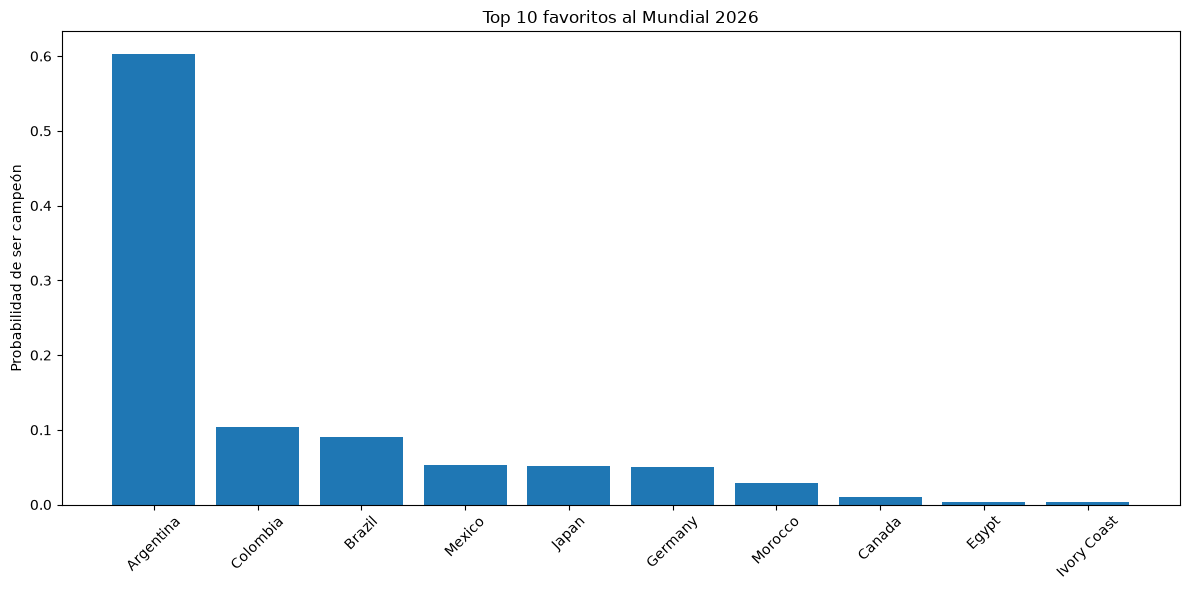

In [44]:
top10 = champions_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["team"],
    top10["probability"]
)

plt.xticks(rotation=45)

plt.ylabel(
    "Probabilidad de ser campeón"
)

plt.title(
    "Top 10 favoritos al Mundial 2026"
)

plt.tight_layout()

plt.show()

In [45]:
champions_df.to_csv(
    "../data/processed/worldcup2026_simulation_results.csv",
    index=False
)

In [47]:
teams_in_round32 = set()

for a, b in round32:
    teams_in_round32.add(a)
    teams_in_round32.add(b)

print(len(teams_in_round32))
print(sorted(teams_in_round32))

32
['Argentina', 'Australia', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Canada', 'Cape Verde', 'Colombia', 'Croatia', 'Ecuador', 'Egypt', 'England', 'France', 'Germany', 'Ivory Coast', 'Japan', 'Jordan', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Norway', 'Panama', 'Paraguay', 'Senegal', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'United States', 'Uruguay', 'Uzbekistan']
